# Conversational Analysis

This notebook contains code to investigate and analyze the conversational building qualities of the PSC:Expresso dataset

In [1]:
from datasets import load_dataset
import pandas as pd

# Load the entire dataset
# dataset = load_dataset("ajd12342/paraspeechcaps")

# Load specific splits of the dataset
# train_scaled = load_dataset("ajd12342/paraspeechcaps", split="train_scaled") #Only has EMilia files
train_base = load_dataset("ajd12342/paraspeechcaps", split="train_base")
holdout = load_dataset("ajd12342/paraspeechcaps", split="holdout")
dev = load_dataset("ajd12342/paraspeechcaps", split="dev")
test = load_dataset("ajd12342/paraspeechcaps", split="test")

dfs = [
    # train_scaled.to_pandas(),
    train_base.to_pandas(),
    holdout.to_pandas(),
    dev.to_pandas(),
    test.to_pandas(),
]

# merge into one dataframe
df = pd.concat(dfs, ignore_index=True)

# filter out VoxCeleb
df = df[df["source"] == "expresso"]
df = df[df["relative_audio_path"].str.contains("conversational_vad_segmented")]

c:\Users\jackm\miniconda3\envs\capstone-eda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# extract columsn for conversation building helpers

import re

def parse_start_time(filename):
    match = re.search(r'_segment_(\d+\.\d+)_', filename)
    return float(match.group(1)) if match else float('inf')

def parse_end_time(filename):
    match = re.search(r'_segment_\d+\.\d+_(\d+\.\d+)\.wav', filename)
    return float(match.group(1)) if match else float('inf')

df['speakers'] = df['relative_audio_path'].str.extract(r'(ex\d+-ex\d+)')
df['high_lvl_style'] = df['relative_audio_path'].str.extract(r'ex\d+-ex\d+/([\w-]+)/')
df['conv_num'] = df['relative_audio_path'].str.extract(r'_(\d+)_channel')
df['start_time'] = df['relative_audio_path'].apply(parse_start_time)
df['end_time'] = df['relative_audio_path'].apply(parse_end_time)


print(df['high_lvl_style'].unique())

['disgusted' 'laughing' 'calm' 'fast' 'enunciated' 'sad-sympathetic'
 'confused' 'desire' 'angry' 'projected' 'sarcastic' 'happy'
 'sympathetic-sad' 'whisper' 'fearful' 'sleepy' 'awe' 'bored']


In [3]:
# Build conv_id from structured columns
df['_conv_id'] = df['speakers'] + '_' + df['high_lvl_style'] + '_' + df['conv_num']

df = df.sort_values(['_conv_id', 'start_time']).reset_index(drop=True)

df['turn_index'] = df.groupby('_conv_id').cumcount()
df['prev_filename'] = df.groupby('_conv_id')['relative_audio_path'].shift(1)




In [ ]:
# pd.set_option('display.max_colwidth', None)
# df

In [6]:
# check for files that are missing from conversations, skipping style folders that arent represented at all
import os

valid_styles = set(df['high_lvl_style'].unique())

wav_files = []
base_dir = "C:/Users/jackm/Documents/GitHub/ms-capstone-TTS-natlang-styleprompts/src/data/raw/paraspeechcaps/audio/expresso/audio_48khz/conversational_vad_segmented"

for root, dirs, files in os.walk(base_dir):
    # check if this directory is under a valid style folder
    style_match = re.search(r'conversational_vad_segmented/[^/]+/([\w-]+)', root.replace('\\', '/'))
    if style_match and style_match.group(1) not in valid_styles:
        continue
    for file in files:
        if file.endswith('.wav'):
            wav_files.append(os.path.join(root, file))

prefix = "C:/Users/jackm/Documents/GitHub/ms-capstone-TTS-natlang-styleprompts/src/data/raw/paraspeechcaps/audio/expresso/"
wav_files_rel = [f.replace('\\', '/').removeprefix(prefix) for f in wav_files]

existing = set(df['relative_audio_path'].values)
missing = [f for f in wav_files_rel if f not in existing]

print(f"Total wav files found: {len(wav_files_rel)}")
print(f"Missing from dataframe: {len(missing)}")


Total wav files found: 12244
Missing from dataframe: 3376


In [7]:
# separate conversations at the missing file, to keep conversations contiguous
df_split = df.copy()
df_split['_is_split_point'] = False

for f in missing:
    match = re.search(r'(ex\d+-ex\d+)_([\w-]+)_(\d+)_channel', f)
    if not match:
        continue
    conv_id = f"{match.group(1)}_{match.group(2)}_{match.group(3)}"
    start = parse_start_time(f)
    if start is not None:
        # only mark the first row at or after the missing file's start time
        idx = df_split[(df_split['_conv_id'] == conv_id) & (df_split['start_time'] >= start)].index
        if len(idx) > 0:
            df_split.loc[idx[0], '_is_split_point'] = True

df_split['_conv_id_split'] = df_split['_conv_id'] + '_part' + df_split.groupby('_conv_id')['_is_split_point'].transform(lambda x: x.cumsum().astype(str))

df_split['turn_index'] = df_split.groupby('_conv_id_split').cumcount()
df_split['prev_filename'] = df_split.groupby('_conv_id_split')['relative_audio_path'].shift(1)

print(f"Original conversations: {df_split['_conv_id'].nunique()}")
print(f"Split conversations: {df_split['_conv_id_split'].nunique()}")

Original conversations: 242
Split conversations: 2311


In [ ]:
# df_split

### visualize conversation length before and after split

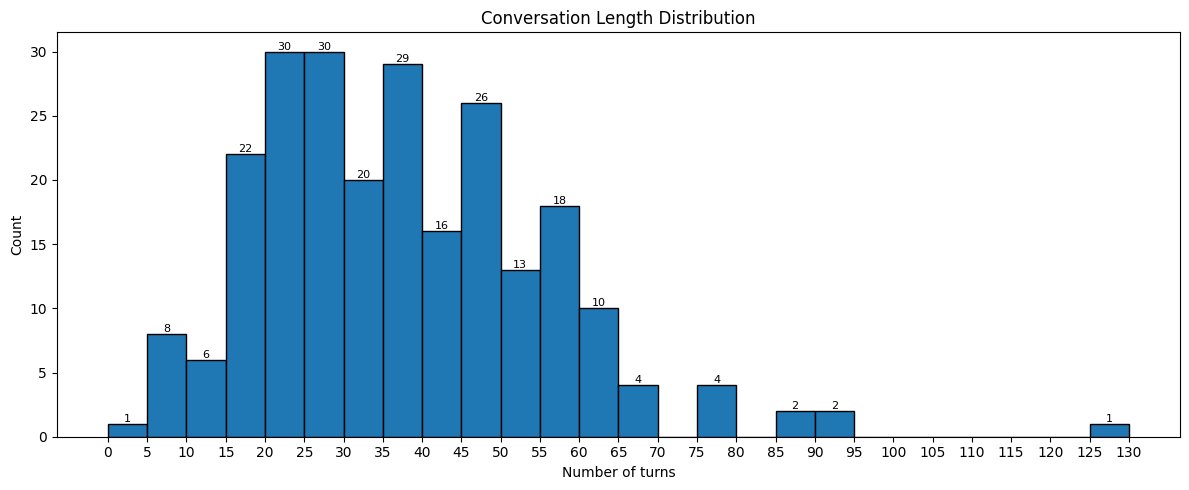

Mean: 36.9, Median: 35, Min: 3, Max: 127


In [8]:
# before split
import matplotlib.pyplot as plt

before = df.groupby('_conv_id')['turn_index'].max() + 1
max_turns = int(before.max())

fig, ax = plt.subplots(figsize=(12, 5))

bins = list(range(0, max_turns + 6, 5))
ax.hist(before, bins=bins, edgecolor='black')
ax.set_title('Conversation Length Distribution')
ax.set_xlabel('Number of turns')
ax.set_ylabel('Count')
ax.set_xticks(bins)

for bar in ax.patches:
    count = int(bar.get_height())
    if count > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print(f"Mean: {before.mean():.1f}, Median: {before.median():.0f}, Min: {before.min()}, Max: {before.max()}")

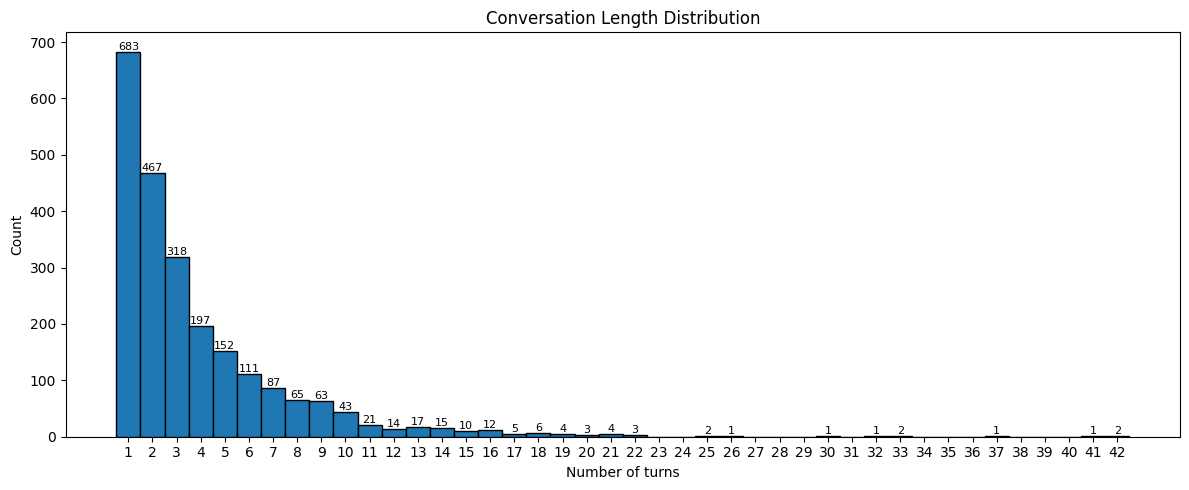

Mean: 3.9, Median: 3, Min: 1, Max: 42


In [9]:
# after split
import matplotlib.pyplot as plt

before = df_split.groupby('_conv_id_split')['turn_index'].max() + 1
max_turns = int(before.max())

fig, ax = plt.subplots(figsize=(12, 5))

bins = [x - 0.5 for x in range(1, max_turns + 2)]

ax.hist(before, bins=bins, edgecolor='black')
ax.set_title('Conversation Length Distribution')
ax.set_xlabel('Number of turns')
ax.set_ylabel('Count')

ax.set_xticks(range(1, max_turns + 1))

for bar in ax.patches:
    count = int(bar.get_height())
    if count > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print(f"Mean: {before.mean():.1f}, Median: {before.median():.0f}, Min: {before.min()}, Max: {before.max()}")